# ML-Based Prognostic Enrichment Pipeline for Treatment Response

This notebook implements a workflow where **machine learning predictions are used to support prognostic patient enrichment** for treatment-response studies.

## Why this notebook exists

This notebook focuses on **prognostic enrichment**. The goal is to determine whether **baseline clinical features and machine-learning predictions** can be used during screening to identify a subgroup of patients who are **more likely to experience a clinically important future outcome**.

In this workflow, the outcome of interest is **treatment response**. Therefore, the enrichment rule is designed to identify a subgroup enriched for likely treatment responders.

The central question is:

**Can we use baseline clinical features and ML at screening to identify a subgroup enriched for likely treatment responders?**

This notebook is designed to answer that question in a way that is useful for both **study design** and **prospective treatment-response screening**.

## Enrichment Framework Overview

This project considers three related but distinct enrichment settings. This notebook focuses on **prognostic enrichment**, where baseline clinical features and machine-learning predictions are used to identify a subgroup enriched for patients who are more likely to experience a clinically important future outcome.

| Enrichment type | Core question | Score thresholded | Status in this notebook |
|---|---|---|---|
| Diagnostic enrichment | Who likely has the disease? | P(disease \| X) | Related prior workflow |
| **Prognostic enrichment** | **Who likely responds or experiences the outcome of interest?** | **`P(response or outcome \| X)`** | **Primary focus** |
| Predictive enrichment | Who benefits more from treatment than control? | Estimated treatment benefit | Future work |

In this notebook, the enrichment score is interpreted as the predicted probability of treatment response. Patients above a fixed probability threshold are selected into the response-enriched subgroup.

Diagnostic enrichment is a related workflow in which the outcome is diagnostic status rather than future response. Predictive enrichment is a more treatment-specific extension that asks whether patients are expected to benefit more from treatment than they would under control or no treatment. Because predictive enrichment requires treatment assignment, control/comparator outcomes, and treatment-effect modeling, it is treated as **future work**.

## Important interpretation note

This workflow evaluates **prognostic enrichment for treatment response**.

It asks:

- **Is this patient likely to respond?**

It does not ask:

- **Is this patient more likely to benefit from treatment compared with control or no treatment?**

Therefore, this notebook should be interpreted as identifying likely responders, not estimating treatment-specific benefit.

## Specific Questions

### Screening / prognostic enrichment for treatment response

- Can baseline clinical features and ML enrich a screened cohort for likely treatment responders?
- What threshold gives an acceptable tradeoff between selected-subgroup response rate and responder capture?
- How many candidates must be screened to enroll the desired response-enriched subgroup?
- How stable is the selected subgroup across repeated model predictions?
- How much does the selected subgroup improve the expected responder proportion relative to the full screened population?

### Trial enablement

- Can this rule improve cohort composition for a treatment-response-focused study?
- Is the selected subgroup sufficiently enriched for likely responders to justify prospective enrichment?
- What sample size is needed to validate the response-enrichment rule in the next study?
- How many total candidates would need to be screened to obtain the required number of selected likely responders?
- What power would a future study have to detect response enrichment over a benchmark response rate?

## Notebook roadmap

This notebook is organized into two chapters:

1. **Threshold-based prognostic enrichment design and study planning for treatment response**  
   Define a fixed enrichment threshold, summarize how that threshold changes selected-subgroup responder composition, and estimate the sample size and power implications for the next study.

2. **Prospective prognostic enrichment workflow for treatment response**  
   Demonstrate how the ensemble model is applied to patient-level data to estimate response probability and determine which patients are selected for response enrichment.

---

# Chapter 1. Threshold-Based Prognostic Enrichment Design and Study Planning

This chapter defines the prognostic enrichment rule using a fixed probability threshold and evaluates how that rule changes the composition of the selected subgroup in the screened population.

The goal is to answer two questions:

1. **What does the threshold do?**  
   How many patients are selected, how enriched is the selected subgroup for likely responders, and how many responders and non-responders are captured or excluded?

2. **What does the threshold imply for the next study?**  
   Given the observed selected response rate, percent selected, and enrichment over the baseline response rate, how many selected patients are needed to validate the enrichment rule with acceptable precision, how many patients would need to be screened to obtain them, and what power would the study have to detect response enrichment over a benchmark response rate?

#### Import packages

In [1]:
import ai_framework.ml_data_preprocessing as mdp
import ai_framework.ml_feature_selection as mfs

import ai_framework.ml_tuning_calib_interpret as mtci
import ai_framework.post_analysis as post
import ai_framework.utils as ut
import ai_framework.validation as vld

import pandas as pd
import numpy as np


##### Load final results and selected features per model

In [2]:
# Load output
all_results       = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)
final_features    = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_features', compress=True)
bundle            = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_bundle', compress=True)

✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_result.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_bundle.pkl.gz


##### Pooled patient risk summary: **"all_trials"**
- all_trials:      ["model","variant","split","group"]

    Pools window-level predictions for a patient across ALL CV runs (trial × outer_fold).
    
    Interpretation: for each patient, pool *all* out-of-sample window-level predictions across all runs, then compute a single patient-level center + spread.

    Note: default assumes you did `StratifiedGroupkfold` hence "group" in all_trials. If not, use unit_col='idx' for `Stratifiedkfold`

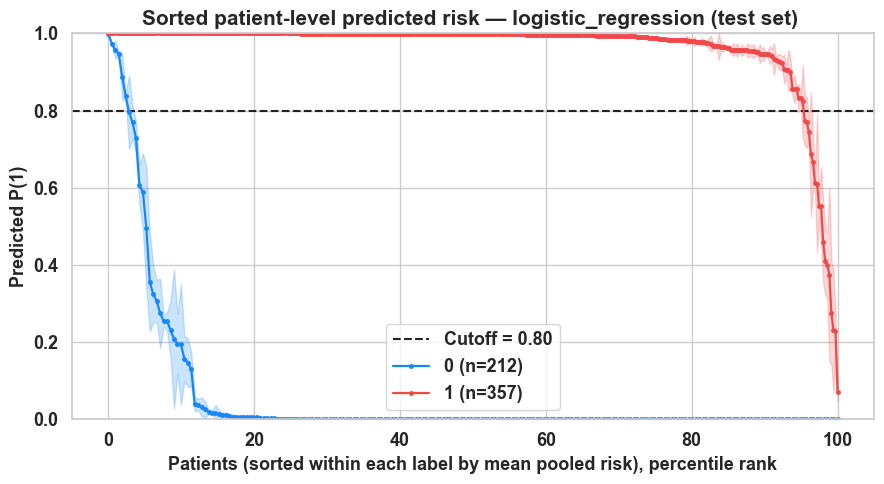

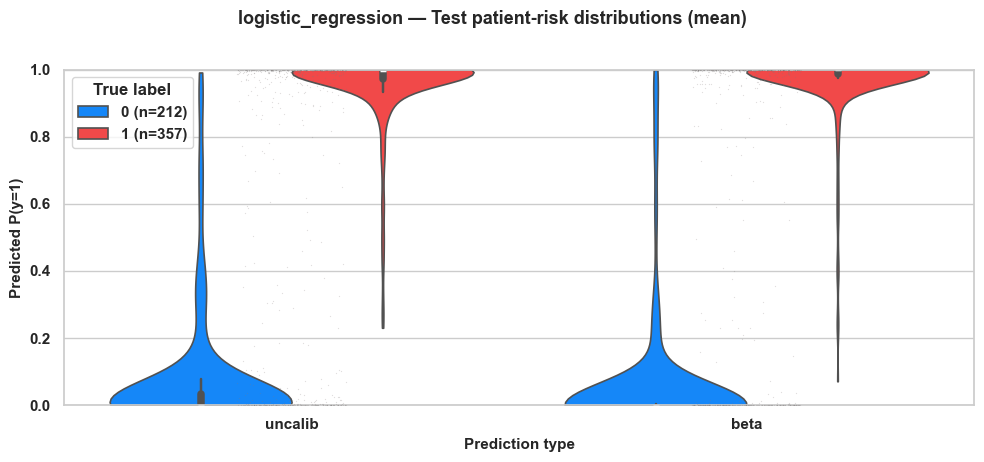

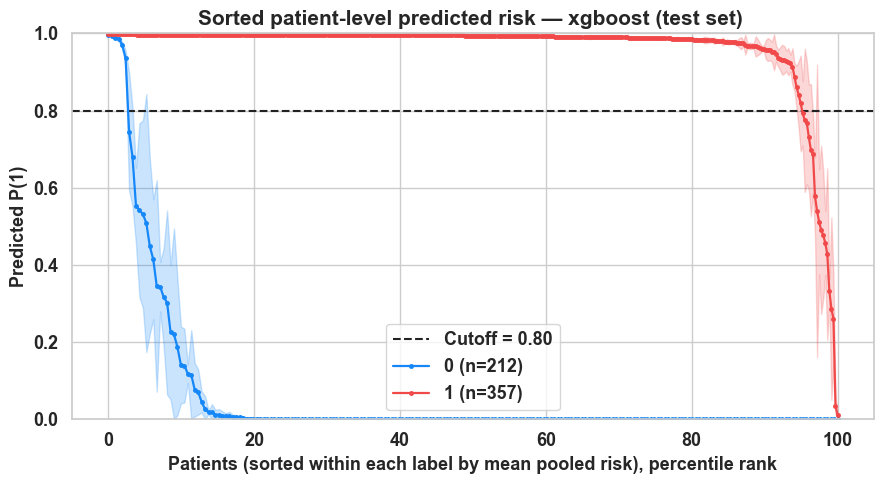

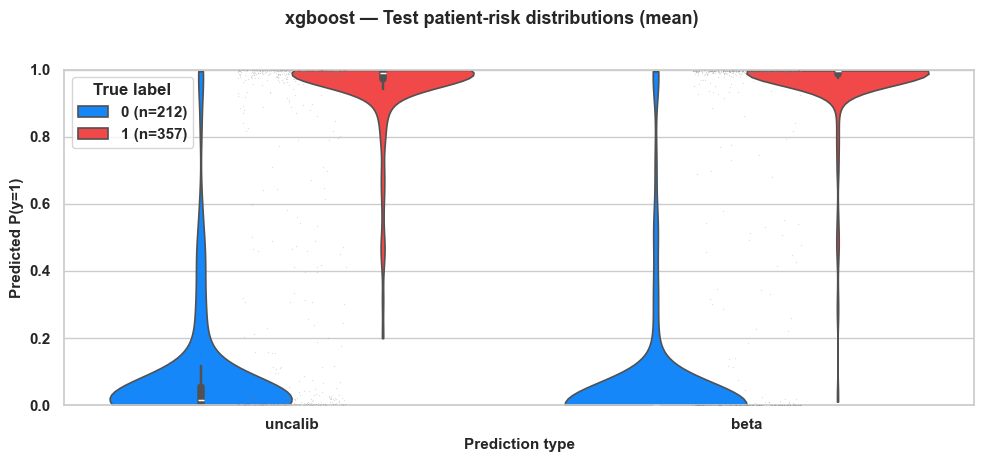

In [3]:

df_long = mtci.build_long_predictions_df(
    all_results,
    model_name=None,
    methods=["beta"],
    groups_all = None,
    group_id_to_key=None,
    include_uncalibrated=True,
    include_test=True,
    include_train_oof=False,   # keep off for now
    unit_col="idx"
)


df_pat = mtci.pooled_patient_risk_summary(
    df_long,
    grouping="all_trials", # per_trial_fold
    unit_col="idx",
    agg="mean",
    lower_q=0.0,
    upper_q=1.0,
    include_test=True,
    include_train_oof=False,
    truncate_decimals=4,
)


# Fixed enrichment threshold:
# patients with predicted probability >= 0.80 are treated as selected
threshold = 0.80

out_pat = mtci.plot_ranked_patients_patient_level(
    df_pat,
    model="logistic_regression",
    variants=[ "beta"],
    colors=["#1587F8", "#F14949"],   # 0, 1 (in the order group_label is detected/sorted)
    split="test",
    group_label=None,               # auto-detect (e.g., 0 + 1)
    center_col="p_mean",
    std_col="p_total_std",
    prob_label=1,
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(9, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='percentile', # or 'index', 'percentile'
)




_ = mtci.plot_patient_risk_distributions_by_outcome(
    df_pat,
    model_name="logistic_regression",
    split="test",
    variants=["uncalib", "beta"],
    value_col="p_mean",
    unit_col="idx",  # or "idx" in the single-row-per-patient world
    outcome_palette={"0 (neg)":  "#1587F8", "1 (pos)": "#F14949"},
    jitter_palette={"0 (neg)": "#817D7D", "1 (pos)": "#817D7D"},
    prevalence=False,
    outcome_legend_alias={"0 (neg)": "0", "1 (pos)": "1"},
)



out_pat_xgb = mtci.plot_ranked_patients_patient_level(
    df_pat,
    model="xgboost",
    variants=[ "beta"],
    colors=["#1587F8", "#F14949"],   # 0, 1 (in the order group_label is detected/sorted)
    split="test",
    group_label=None,               # auto-detect (e.g., 0 + 1)
    center_col="p_mean",
    std_col="p_total_std",
    prob_label=1,
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(9, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='percentile', # or 'index', 'percentile'
)


_ = mtci.plot_patient_risk_distributions_by_outcome(
    df_pat,
    model_name="xgboost",
    split="test",
    variants=["uncalib", "beta"],
    value_col="p_mean",
    unit_col="idx",  # or "idx" in the single-row-per-patient world
    outcome_palette={"0 (neg)":  "#1587F8", "1 (pos)": "#F14949"},
    jitter_palette={"0 (neg)": "#817D7D", "1 (pos)": "#817D7D"},
    prevalence=False,
    outcome_legend_alias={"0 (neg)": "0", "1 (pos)": "1"},
)





## Threshold-Based Prognostic Enrichment Analysis

This section applies the fixed prognostic enrichment threshold to patient-level predictions in order to define a selected response-enriched subgroup.

The enrichment analysis is summarized at three levels:

1. **Pocket summary**  
   Describes the selected subgroup itself, including the number selected, the selected response rate, the selected non-response rate, and the response enrichment factor relative to the full screened population.

2. **Operating summary**  
   Describes what the threshold does in the full screened population, including responder capture rate, non-responder exclusion rate, non-selected non-response rate, percent selected, screen-fail rate, and screening burden.

3. **Planning summary**  
   Uses the observed selected response rate and percent selected to estimate how many selected patients are needed to validate the enrichment rule with a desired level of precision, and how many total patients would need to be screened to obtain them. When power planning is enabled, this summary also estimates the probability of detecting response enrichment over a benchmark response rate.

### Why this is useful

Clinical data may not separate responders from non-responders equally well across the entire screened population. This analysis supports the hypothesis that **prognostic separability is heterogeneous**: there may exist subsets of individuals for whom baseline clinical data provides a stronger and more consistent signal of future treatment response.

Identifying and quantifying these response-enriched pockets can support focused follow-up analyses and motivate enrichment strategies for future studies, such as prioritizing patients who are more likely to respond for deeper phenotyping, prospective validation, or treatment-response-focused trial design.

In [4]:

# Fixed prognostic enrichment threshold:
# patients with predicted probability of treatment response >= 0.70
# are treated as selected into the response-enriched subgroup.
threshold = 0.70

# Run the prognostic enrichment pipeline for each model in df_pat.
#
# This wrapper reuses the generic threshold-based enrichment machinery,
# but interprets the positive class as "responder" and renames summary
# outputs using treatment-response terminology.
#
# For every model, it does four things:
#   1. computes the pocket summary for the response-enriched subgroup,
#   2. computes the threshold operating summary in the full eligible population,
#   3. computes response-rate precision planning for the next study,
#   4. computes binary-endpoint power planning to evaluate whether the
#      selected subgroup response rate can be detected as higher than a
#      benchmark response rate.
#
# By default, power planning uses:
#   - observed selected response rate as the assumed enriched rate,
#   - observed baseline response rate as the benchmark rate,
#   - observed selected N as the selected sample size,
#   - a one-sided "larger" test,
#   - binomial power for the binary responder/non-responder endpoint.
out = post.prognostic_enrichment_pipeline_by_model(
    df=df_pat,                           # patient-level prediction table used for prognostic enrichment analysis
    threshold=threshold,                 # fixed cutoff used to define the response-enriched subgroup
    model=None,                          # run all available models in df_pat
    score_col="p_mean",                  # patient-level predicted probability of response used for thresholding
    variants="beta",                     # use the beta-calibrated model outputs
    split="test",                        # evaluate the threshold on the test split
    meta_cols=["model", "variant", "split"],  # metadata columns to keep in summary outputs
    drop_subject_ids=None,               # no manual subject exclusions applied here
    subject_col="idx",                   # subject identifier column
    y_col="y",                           # binary response outcome; y=1 is interpreted as responder
    label_col="group_label",             # human-readable response/non-response label column, if available
    confidence=0.95,                     # precision planning uses a 95% confidence interval
    precision=0.05,                      # target half-width for selected response-rate precision (± 0.05)

    # Power planning
    compute_power=True,                  # add power-based planning columns to planning_summary
    power_alpha=0.05,                    # type I error rate for the power calculation
    power_alternative="larger",          # test whether selected response rate > benchmark response rate
    power_endpoint="binary",             # current endpoint is responder vs non-responder
    power_method="binomial",             # use binomial power for the binary endpoint
    power_assumed_enriched_rate=None,    # None => use observed selected response rate
    power_benchmark_rate=None,           # None => use observed baseline response rate
    power_selected_n=None,               # None => use observed n_selected
)

# ---------------------------
# Logistic regression outputs
# ---------------------------

# Pocket summary for logistic regression:
# describes only the threshold-selected response-enriched subgroup
# (for example: n_selected, selected_response_rate,
# selected_nonresponse_rate, response_enrichment_factor)
pocket_lr = out["logistic_regression"]["pocket_summary"]

# Operating summary for logistic regression:
# describes what the response-probability threshold is doing in the
# full eligible population
# (for example: responder_capture_rate, nonresponder_exclusion_rate,
# nonselected_nonresponse_rate, percent selected, number needed to screen)
oper_lr = out["logistic_regression"]["operating_summary"]

# Planning summary for logistic regression:
# uses selected response rate and percent selected to estimate
# how many selected patients are needed and how many total candidates
# must be screened in the next study
plan_lr = out["logistic_regression"]["planning_summary"]

# Threshold-selected patients for logistic regression:
# this is the response-enriched subgroup itself
# (patients with predicted probability of response above threshold)
df_hi_lr = out["logistic_regression"]["df_hi"]

# Full eligible population for logistic regression:
# this is the denominator population before response-thresholding
df_all_lr = out["logistic_regression"]["df_all"]

# ---------------------------
# XGBoost outputs
# ---------------------------

# Pocket summary for XGBoost:
# describes only the threshold-selected response-enriched subgroup
# (for example: n_selected, selected_response_rate,
# selected_nonresponse_rate, response_enrichment_factor)
pocket_xgb = out["xgboost"]["pocket_summary"]

# Operating summary for XGBoost:
# describes the response-probability threshold as a prognostic screening rule
# in the full eligible population
# (for example: responder_capture_rate, nonresponder_exclusion_rate,
# nonselected_nonresponse_rate, percent selected, number needed to screen)
oper_xgb = out["xgboost"]["operating_summary"]

# Planning summary for XGBoost:
# estimates required selected and screened sample sizes for validating
# the selected response rate with the desired precision
plan_xgb = out["xgboost"]["planning_summary"]

# Threshold-selected patients for XGBoost:
# this is the response-enriched subgroup itself
df_hi_xgb = out["xgboost"]["df_hi"]

# Full eligible population for XGBoost:
# this is the full pre-threshold population for comparison
df_all_xgb = out["xgboost"]["df_all"]

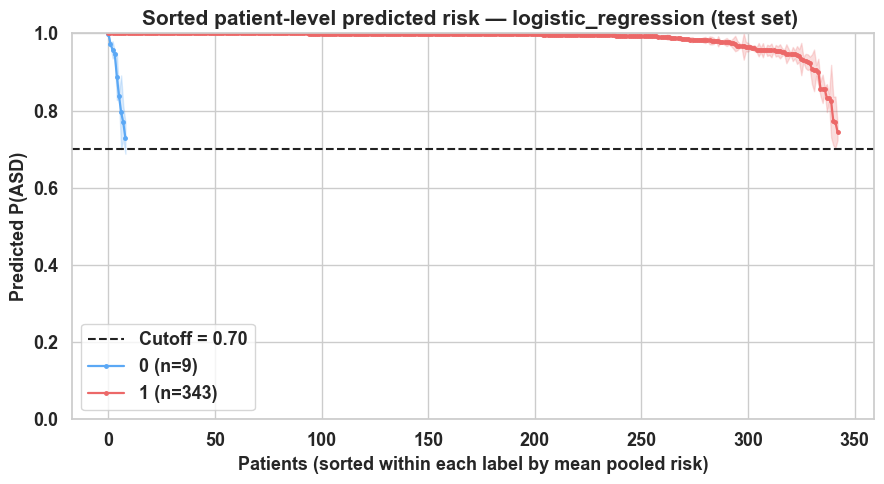

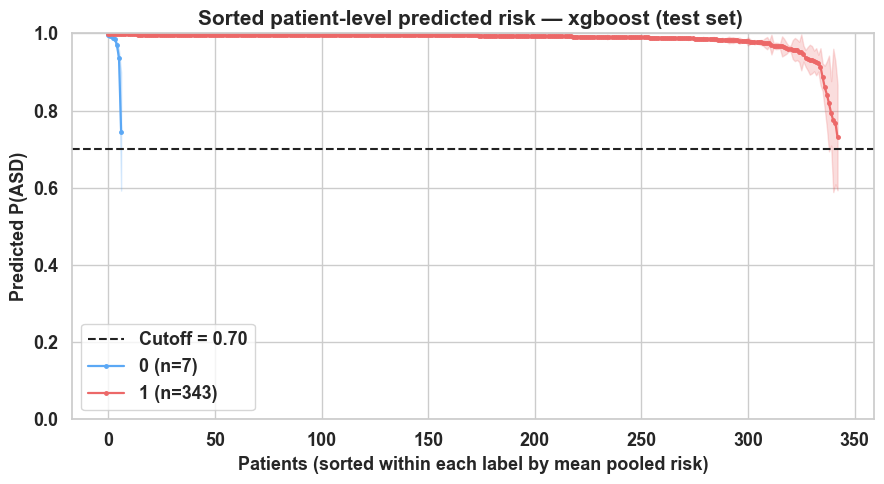

,0,1
model,logistic_regression,xgboost
variant,beta,beta
split,test,test
score_col,p_mean,p_mean
thr_low,0.7,0.7
thr_high,1.0,1.0
n_total,569,569
n_responders_total,357,357
n_nonresponders_total,212,212
n_selected,352,350


In [5]:
_ = mtci.plot_ranked_patients_patient_level(
    df_hi_lr,
    model=None,
    variants=[ "beta"],
    colors=["#5BA8F5", "#EC6868"],   # ASD, TD (in the order group_label is detected/sorted)
    split="test",
    group_label=None,               # auto-detect (e.g., ASD + TD)
    center_col="p_mean",
    std_col="p_total_std",
    prob_label="ASD",
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(8, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='index', # or 'index', 'percentile'
)


_ = mtci.plot_ranked_patients_patient_level(
    df_hi_xgb,
    model=None,
    variants=[ "beta"],
    colors=["#5BA8F5", "#EC6868"],   # ASD, TD (in the order group_label is detected/sorted)
    split="test",
    group_label=None,               # auto-detect (e.g., ASD + TD)
    center_col="p_mean",
    std_col="p_total_std",
    prob_label="ASD",
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(8, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='index', # or 'index', 'percentile'
)



planning_table = pd.concat(
    [v["planning_summary"] for v in out.values()],
    axis=0,
    ignore_index=True,
)

display(planning_table.T)




# Chapter 2. Prospective enrichment workflow

This chapter demonstrates how the fixed enrichment rule is applied prospectively to patient-level data.

Given a set of screened patients, the ensemble model generates a patient-level predicted probability for each patient. The enrichment threshold is then applied to determine which patients are selected for the enriched cohort and which patients are not selected.

## 2.1 Example patient cohort
To illustrate how the enrichment rule is used in practice, we generate an example patient cohort based on balanced semi-synthetic sampling from the original dataset.

These example patients are used only to demonstrate the screening workflow and are not used to redefine the threshold.

In [6]:

# Features used for model development: Select top k features
top_k = 7
lr_top = final_features['final_by_model']['logistic_regression']['feature_names_selected'][:top_k]
xgb_top  = final_features['final_by_model']['xgboost']['feature_names_selected'][:top_k]


feature_filters = {
    "logistic_regression": lr_top,
    "xgboost": xgb_top
}

model_data_dict = post.synthetic_data_validation(
    final_features=final_features,
    feature_filters=feature_filters,
    make_semisynthetic=True,
    semisynthetic_n_per_class=20,
    semisynthetic_noise_scale=0.15,  # 15% of each feature's SD
    semisynthetic_clip_to_observed_range=True,
    semisynthetic_random_state=42,
)


## 2.2 Ensemble scoring and enrichment decision
For each example patient, repeated model predictions are aggregated to obtain a patient-level ensemble probability.

Patients with predicted probability above the fixed threshold are selected for enrichment, while patients below the threshold are not selected.

In [7]:
# Synthetic data prep.
cols_lg = lr_top + ['y']
cols_xgb =   xgb_top + ['y']

test_data = {}
test_data['logistic_regression'] = model_data_dict['logistic_regression']['df_semisynthetic'][cols_lg]
test_data['xgboost']             = model_data_dict['xgboost']['df_semisynthetic'][cols_xgb]


# Generate external-set predictions for every fold model in `all_results` and store them back into each fold record using `*_external_*` keys (metrics only if labels exist).
#all_results    = mtci.load_all_results(output_dir='abcct_dataset_outputs/run_1/nonlinear_features', prefix='final_result', compress=True)
#all_results       = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)

all_results = vld.add_external_predictions_to_results(
    all_results,
    model_data_dict=test_data,
    y_col=None,   # or None if unlabeled, or just add the label column if present
    external_tag="external",
    feature_names_key="feature_names_used",
    strict_features=True,
)


# Build a single long-form  predictions table with one row per predicted example that is pooled across models. 
df_long = vld.build_long_predictions_df(
    all_results,
    model_name=None,
    methods=["beta"],
    include_uncalibrated=False,
)

# Aggregate repeated predictions per idx into a single row per (model, variant, idx), and optionally add an "ensemble" model by pooling predictions across multiple models.
df_agg = vld.aggregate_predictions_by_idx(
    df_long,
    calibrations=["uncalib", "beta"],
    add_ensemble=True,
    ensemble_name="Ensemble model",
    ensemble_models=None, #["logistic_regression", "xgboost"],  # optional; otherwise pools all selected
    truncate_decimals=4,
)

df_agg.head()

,model,calibration,idx,y,n_preds,p_mean,p_median,p_std,p_min,p_max,split,y_label,prevalence_used
0,Ensemble model,beta,0,NaN,30,0.2760,0.2923,0.1996,0.0018,0.6959,external,NaN,NaN
1,Ensemble model,beta,1,NaN,30,0.0223,0.0009,0.0697,0.0000,0.3019,external,NaN,NaN
2,Ensemble model,beta,2,NaN,30,0.0000,0.0000,0.0002,0.0000,0.0009,external,NaN,NaN
3,Ensemble model,beta,3,NaN,30,0.9951,0.9967,0.0049,0.9867,0.9999,external,NaN,NaN
4,Ensemble model,beta,4,NaN,30,0.0000,0.0000,0.0001,0.0000,0.0007,external,NaN,NaN


### Plot ranked screening predictions for enrichment decision-making.

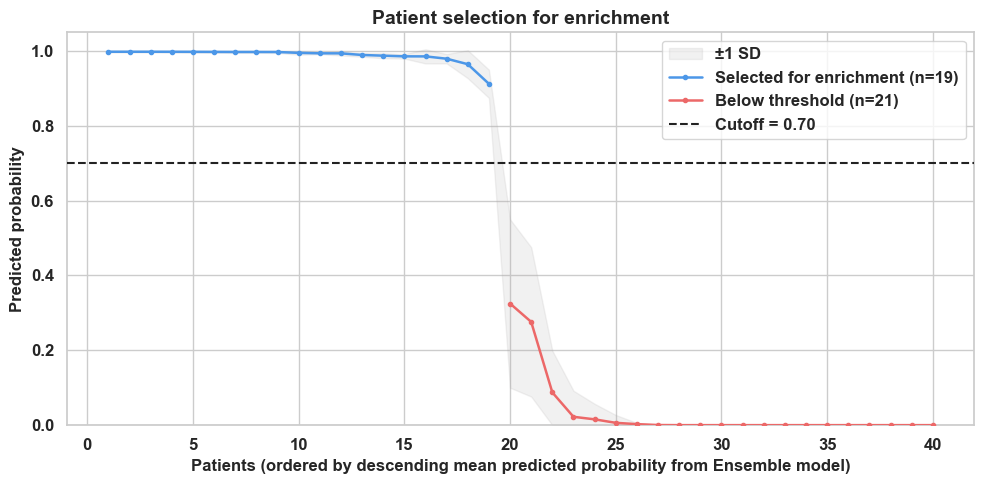

In [8]:
# In this example, we plot only the Ensemble model, so the function will:
#   1. order patients by the Ensemble model's p_mean values,
#   2. color patients above the cutoff as "selected for enrichment",
#   3. color patients at/below the cutoff as "below threshold",
#   4. show a neutral uncertainty ribbon using p_std.
ranked_dict = vld.plot_screening_predictions(
    df_pred=df_agg,                      # aggregated patient-level prediction table
    models=["Ensemble model"],           # models to plot; here we only show the Ensemble model
    # models=["logistic_regression", "xgboost", "Ensemble model"],  # example multi-model call

    reference_order_model="Ensemble model",  # model used to define the shared patient order on the x-axis
    calibration="beta",                 # use beta-calibrated probabilities
    center_col="p_mean",                # patient-level summary score used for ranking and thresholding
    std_col="p_std",                    # patient-level uncertainty column used for the ±1 SD ribbon

    figsize=(10, 5),                    # figure width and height
    cutoff=threshold,                        # fixed enrichment threshold: patients above this are considered selected
    ylim=(0, 1.05),                     # y-axis range; slight padding above 1.0 improves readability

    method_alias={                      # nicer display names used only in the plot labels
        "logistic_regression": "Logistic regression",
        "xgboost": "XGBoost",
        "Ensemble model": "Ensemble model",
    },

    ribbon_color_single_model="#ADAAAA",  # neutral ribbon color for the single-model case
    title_prefix="Patient selection for enrichment",  # plot title
)


In [9]:
ranked_dict['Ensemble model'].head(3)

,model,calibration,idx,y,n_preds,p_mean,p_median,p_std,p_min,p_max,split,y_label,prevalence_used,patient_rank,selected_for_enrichment
0,Ensemble model,beta,39,NaN,30,0.9981,0.9986,0.002,0.9926,0.9999,external,NaN,NaN,1,True
1,Ensemble model,beta,27,NaN,30,0.9981,0.9985,0.002,0.9926,0.9999,external,NaN,NaN,2,True
2,Ensemble model,beta,30,NaN,30,0.9981,0.9986,0.002,0.9925,0.9999,external,NaN,NaN,3,True
